0.4050999999999997


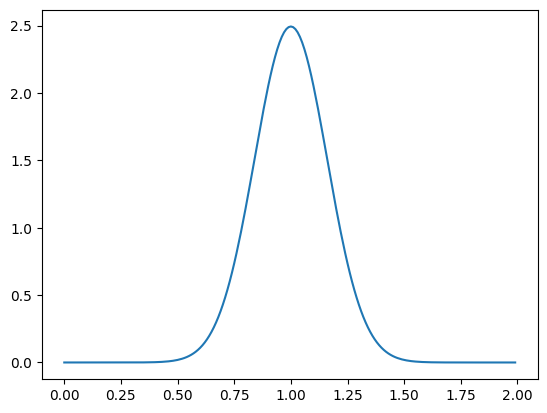

In [1]:
from matrix import*  
from solver import Newmarksuper_HSI2,accdyn_super,Newmarkpseudo_HSI2
from pedestrian import* 
from matplotlib import pyplot as plt
import timeit
import numpy as np
from scipy.stats import norm
from pseudo_excitation import*
from ZIV_SM import compute_subharmonic_dlf, compute_dlf

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80    #kg
peddamp = 0    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 0 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,  )                   #modes


N_bridge = 2

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

pace = mean_pace
mean_DLF1 = -0.2649*pace**3 +1.3206*pace**2-1.7597*pace+0.7613
print(mean_DLF1)

t = np.array(np.arange(0, (50+1) / 1.25, 0.01)) 

DLF2 = 0.07
DLF3 = 0.05
DLF4 = 0.05
DLF5 = 0.03 
DLF=np.array([mean_DLF1, DLF2, DLF3, DLF4, DLF5])

STD_DLF2 = 0.03
STD_DLF3 = 0.02
STD_DLF4 = 0.02
STD_DLF5 = 0.015


""" Data from the table for Harmonics Zivanovic and Pavic (2007)"""
i_values = [1, 2, 3, 4, 5]
a_i1_values = [0.785200, 0.513000, 0.390800, 0.325500, 0.280600]
b_i1_values = [0.999900, 2.000000, 3.000000, 4.000000, 4.999000]
c_i1_values = [0.008314, 0.011050, 0.009560, 0.008797, 0.007939]

a_i2_values = [0.020600, 0.133000, 0.156700, 0.164700, 0.158400]
b_i2_values = [1.034000, 1.957000, 3.000000, 4.001000, 5.004000]
c_i2_values = [0.252400, 0.263200, 0.055250, 0.066410, 0.078250]

a_i3_values = [0.107400, -0.049840, 0.068660, 0.068880, 0.072890]
b_i3_values = [1.001000, 1.882000, 2.957000, 3.991000, 4.987000]
c_i3_values = [0.036530, 0.058070, 0.560700, 0.375000, 0.450100]



""" Data from the table for Sub Harmonics Zivanovic and Pavic (2007)"""
a_s_i1_values = [0.340600, 0.302400, 0.262700, 0.234400, 0.264500]
b_s_i1_values = [0.498800, 1.500000, 2.500000, 3.501000, 4.499000]
c_s_i1_values = [0.008337, 0.008735, 0.009748, 0.009898, 0.010190]
a_s_i2_values = [0.280300, 0.134500, 0.245600, 0.235500, 0.238900]
b_s_i2_values = [1.133000, 1.532000, 0.231200, -1.576000, 1.153000]
c_s_i2_values = [0.638800, 0.723300, 2.932000, 7.050000, 4.561000]



x1 = np.arange(0, 2, 0.01) #multilpication factor transforming mean DLF into the distribution of DLF
pdf = norm.pdf(x1,1, 0.16)
#DLF1 = mean_DLF1*pdf
plt.plot(x1, pdf)
plt.show()

DLF_s_1= 0.026*mean_DLF1 + 0.0031
DLF_s_2= 0.074*mean_DLF1 + 0.01   
DLF_s_3= 0.012*mean_DLF1 + 0.016
DLF_s_4= 0.013*mean_DLF1 + 0.0093
DLF_s_5= 0.015*mean_DLF1 + 0.0072

DLF_s = np.array([DLF_s_1, DLF_s_2, DLF_s_3, DLF_s_4, DLF_s_5])

In [16]:
f_values = [pace, 2*pace, 3*pace, 4*pace, 5*pace]
i_values = [1,2,3,4,5]
dlf_values = []
x = np.linspace(0, 10, 1000)
sin = np.zeros(t.size)

for i in range(np.size(i_values)):
    f = f_values[i]
    f_range = np.arange(f - 0.5, f + 0.5,1/80)

    dlf_values = [compute_dlf(f_val, i,pace) for f_val in f_range]
    for k in range(np.size(f_range)):
        sin += dlf_values[k]*np.sin(2*np.pi*f_range[k]*t)*750*DLF[i]

    f_range2 = np.arange(f - 1.5, f - 0.5, 1/80)  # Adjust the step size as needed
    dlf_values2 = [compute_subharmonic_dlf(f_val, i,pace) for f_val in f_range2]

    for k in range(np.size(f_range2)):
        sin += dlf_values2[k]*np.sin(2*np.pi*f_range2[k]*t)*750*DLF_s[i]
print(dlf_values)
print(sin)
#plt.plot(t, sin)    

[0.05524473478635826, 0.05605046499401766, 0.05684767646769562, 0.057636578504855346, 0.058417865546925615, 0.05919292498762784, 0.059964115772218635, 0.06073513360065597, 0.06151147819927388, 0.062301035609103335, 0.06311478287874404, 0.06396761305902707, 0.06487926422444161, 0.06587531697649639, 0.06698820067738227, 0.06825812051114266, 0.06973378742530827, 0.07147280431756645, 0.0735415389311244, 0.07601430219013486, 0.07897165597659488, 0.08249770213807157, 0.0866762590168081, 0.09158591475224982, 0.09729405624349081, 0.10385010281644745, 0.11127831347711536, 0.11957067097091267, 0.12868045639816372, 0.13851719544025243, 0.14894366350777435, 0.1597755691504415, 0.17078438725330697, 0.18170359009468717, 0.19223824054965197, 0.202077730174423, 0.21094015809138938, 0.2203322757865257, 0.25882156448896665, 0.40978272982644237, 0.5069989730442056, 0.3528979374016059, 0.24476833074728782, 0.22597471599695923, 0.21977121246068376, 0.2124983816902525, 0.20385141563863723, 0.194113274715243

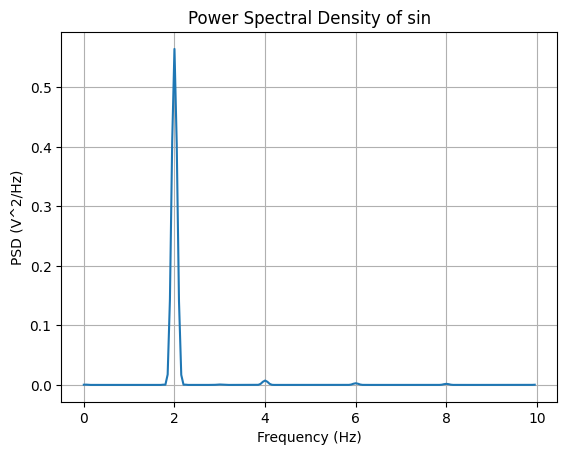

In [15]:
from scipy.signal import welch
# Compute the PSD of the sin signal
fs = 1 / (t[1] - t[0])  # Sampling frequency
frequencies, psd = welch(sin, fs=fs,nperseg=1000, nfft=2000 )
frequencies = np.array(frequencies)
psd = np.array(psd)
frequencies=frequencies[frequencies<(10)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]

# Plot the PSD
plt.figure()
plt.plot(frequencies, psd/(80*9.81)**2) 
plt.title("Power Spectral Density of sin")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V^2/Hz)")
plt.grid(True)
plt.show()

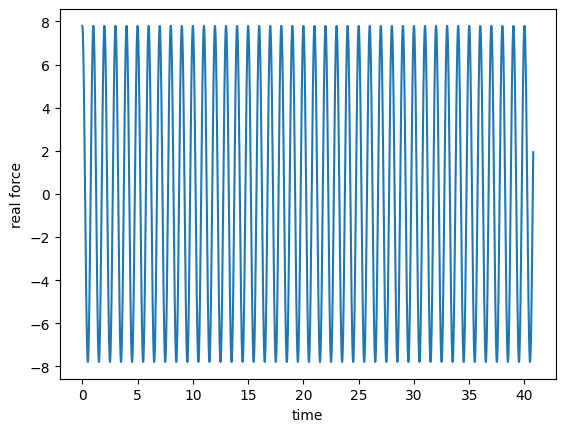

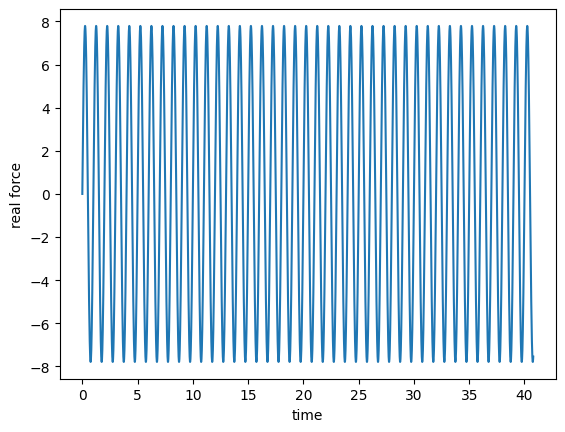

In [5]:
real,imaginary = pseudo_excitation(psd,frequencies,50,1.25,t)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

[[ 0.00000000e+00  1.01335194e-04  2.00950633e-04 ... -1.56197926e-04
  -2.55899149e-04  0.00000000e+00]
 [ 0.00000000e+00  1.91049864e-04  3.35902090e-04 ... -7.35381829e-05
  -2.20093939e-04  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  1.21321417e-04  2.40582696e-04 ... -1.87184817e-04
  -3.06779224e-04  0.00000000e+00]
 [ 0.00000000e+00  2.28730406e-04  4.02149411e-04 ... -8.80361583e-05
  -2.63520640e-04  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  7.10585813e-05  1.40908425e-04 ... -1.09952633e-04
  -1.80404168e-04  0.00000000e+00]
 [ 0.00000000e+00  1.33968582e-04  2.35537023e-04 ... -5.15529057e-05
  -1.54376736e-04  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  2.42757489e-05  4.81373587e-05 ..

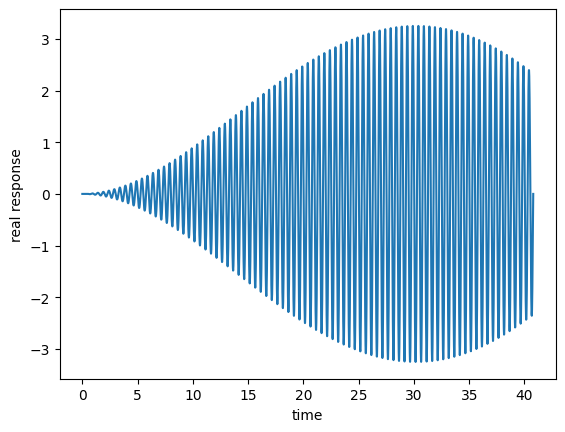

In [6]:
Real_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)

In [7]:
import pickle
with open('Real_responce_ZIV_SMNOHSI.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_ZIV_SMNOHSI.pkl")

Matrix saved to Real_responce_ZIV_SMNOHSI.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.00000000e+00 0.00000000e+00 7.62283456e-07 ... 4.90432583e-05
  4.78670589e-05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.43715139e-06 ... 5.21458172e-06
  4.66136869e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 8.92942318e-07 ... 5.76671949e-05
  5.62853069e-05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.68348569e-06 ... 6.10985498e-06
  5.46175447e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 4.57580171e-07 ... 2.97383695e-05
  2.90267239e-05 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.62686935e-07 ... 3.13219586e-06
  2.80002776e-06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+0

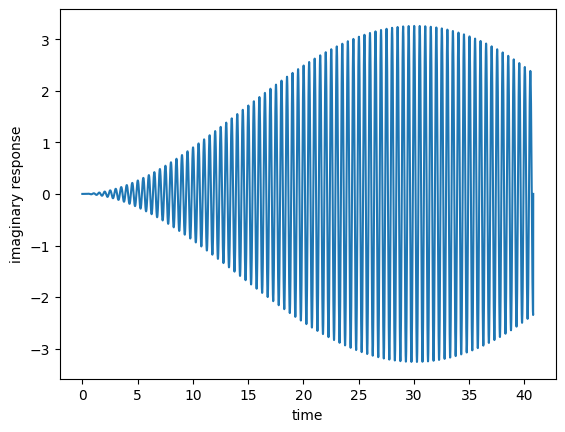

In [8]:
imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI2(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)



plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd) 

In [9]:
import pickle
with open('imag_responce_ZIV_SMNOHSI.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_ZIVNOHSI_SM.pkl")

Matrix saved to imag_responce_ZIVNOHSI_SM.pkl


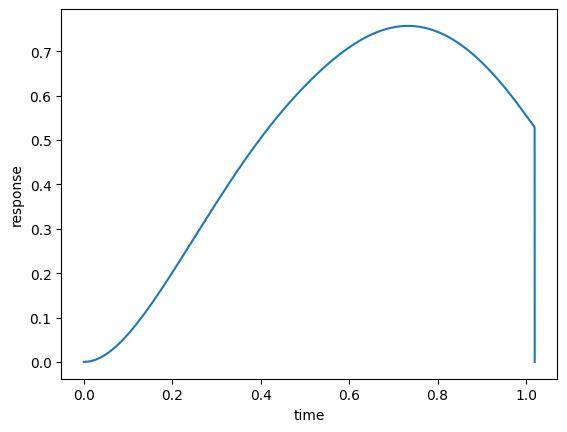

In [10]:
with open('Real_responce_ZIV_SMNOHSI.pkl', 'rb') as f1:
    Real_responce = pickle.load(f1)
with open('imag_responce_ZIV_SMNOHSI.pkl', 'rb') as f2:
    imag_responce = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce[[j],[i]]**2 + imag_responce[[j],[i]]**2)*delta_f

deterministic_RMS=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),deterministic_RMS.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()

In [12]:
import pickle
with open('ZIV_SM_NOHSI.pkl', 'wb') as f:
    pickle.dump(deterministic_RMS, f)

print("Matrix saved to ZIV_SM_NOHSI.pkl")

Matrix saved to ZIV_SM_NOHSI.pkl


In [11]:
# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(deterministic_RMS)

# Print the maximum RMS value and its corresponding time
print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")


Maximum 0.5-second RMS value: 0.7573 m/s^2 
